# RAGMAR Offline Analysis


In [24]:
from pathlib import Path
import json, re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 80)
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (10, 4),
    "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})

# ============================================================================
# SWAP THE DATA SET HERE  -  this block is the only place a folder is named.
# Point RESULTS_DIR at any directory laid out like results_small/ (configs/,
# offline/, hardware/, runs/) and re-run the notebook top to bottom. Copy this
# notebook, change the one line, and the full-run dump analyses itself.
# ============================================================================
RESULTS_DIR  = "results_small"    # e.g. "results_full", "results_new"
BASELINE_JOB = None               # SLURM id of the reference arm; None = earliest job present
# ============================================================================

ROOT    = Path.cwd().parent if Path.cwd().name.lower() == "analysis" else Path.cwd()
RESULTS = ROOT / RESULTS_DIR
# Figures are namespaced by data set, so a copy of this notebook pointed at a
# different dump cannot silently overwrite the figures of this one.
FIGS    = ROOT / "Analysis" / "figures" / RESULTS_DIR / "offline"
FIGS.mkdir(parents=True, exist_ok=True)

if not RESULTS.is_dir():
    raise SystemExit("RESULTS_DIR does not exist: " + str(RESULTS))

# results/ is laid out by artefact kind: configs/, offline/, hardware/, runs/.
#   configs/redundent/ holds runs excluded from this analysis by hand (the 120165 and
#     121764 rebuilds) - their traces, configs and hardware CSVs all live in there.
#   old/ is a previous experiment generation with a different trace schema.
# Both are skipped everywhere, so nothing below can pick them up by accident.
SKIP_DIRS = {"redundent", "old"}

STAGES       = ["read", "chunk", "embed", "index"]
STAGE_COLOR  = {"read": "#8C8C8C", "chunk": "#4C72B0", "embed": "#DD8452", "index": "#55A868"}
EMBED_DIM    = {"all-MiniLM-L6-v2": 384, "multi-qa-mpnet-base-dot-v1": 768}
EMBED_MAXTOK = {"all-MiniLM-L6-v2": 256, "multi-qa-mpnet-base-dot-v1": 512}
CHARS_PER_TOKEN = 4.0   # rough English-prose ratio for WordPiece/BPE; used only in section 5


def find(pattern):
    # Every file under results/ matching `pattern`, at whatever depth its artefact kind
    # puts it, skipping SKIP_DIRS. Deduplicated by filename so that a future re-copy of
    # the same artefact into a second directory cannot double-count a run.
    seen = {}
    for p in sorted(RESULTS.rglob(pattern)):
        if SKIP_DIRS & set(p.relative_to(RESULTS).parts[:-1]):
            continue
        seen.setdefault(p.name, p)
    return [seen[k] for k in sorted(seen)]


print("data set:", RESULTS)
print("figures :", FIGS)
for kind, pat in [("configs ", "*_config.json"),
                  ("traces  ", "offline_*.json"),
                  ("hardware", "hardware_offline_*.csv"),
                  ("index   ", "*.index.faiss")]:
    hits = find(pat)
    where = sorted({str(p.parent.relative_to(RESULTS)) for p in hits}) or ["-"]
    print("{}: {:>2} file(s) in {}".format(kind, len(hits), ", ".join(where)))

skipped = sorted({p.name for d in SKIP_DIRS for p in RESULTS.rglob(d + "/*")})
print("\nexcluded by SKIP_DIRS:", ", ".join(skipped) or "nothing")

root    : c:\Users\Jespe\Desktop\BACKUP_UNI\ITU\Masters\Thesis RAG Systems\RAGNAR
configs :  4 file(s) in configs
traces  :  4 file(s) in offline
hardware:  4 file(s) in hardware
index   :  0 file(s) in -

excluded by SKIP_DIRS: FAISSDB_120165.index_config.json, FAISSDB_121764.index_config.json, hardware_offline_120165.csv, hardware_offline_121764.csv, offline_FAISSDB_120165.json, offline_FAISSDB_121764.json


## 1. Load the build traces

One row per run in `runs`, one row per batch in `batches`. The arm label is not
hard-coded — it is computed by diffing each run's resolved config against the baseline's,
so adding a new arm to `configs/` and re-running the notebook labels itself.

In [25]:
def flatten(d, prefix=""):
    out = {}
    for k, v in d.items():
        key = prefix + k
        if isinstance(v, dict):
            out.update(flatten(v, key + "."))
        else:
            out[key] = v
    return out


OFFLINE_PREFIXES = ("chunker.", "embedder.", "index.", "offline.")


def load_configs():
    cfgs = {}
    for p in find("*_config.json"):
        d = json.loads(p.read_text(encoding="utf-8"))
        cfgs[str(d["job_id"])] = d
    return cfgs


CFG = load_configs()

# Resolve the reference arm against the data set that actually loaded, so a
# swapped-in results folder needs no second edit. An explicit BASELINE_JOB that
# is not present in the dump is a typo, not a fallback - say so.
if BASELINE_JOB is None:
    BASELINE_JOB = sorted(CFG)[0]
    print("BASELINE_JOB auto-selected (earliest job in dump):", BASELINE_JOB)
elif BASELINE_JOB not in CFG:
    raise SystemExit("BASELINE_JOB " + BASELINE_JOB + " has no config in " + str(RESULTS)
                     + "; present: " + ", ".join(sorted(CFG)))


def offline_flat(job):
    f = flatten(CFG[job]["resolved"])
    # index.chroma.* is carried by every config regardless of backend, so it would
    # otherwise show up as a spurious diff for the FAISS arms.
    return {k: v for k, v in f.items()
            if k.startswith(OFFLINE_PREFIXES) and not k.startswith("index.chroma.")}


def arm_change(job, base=BASELINE_JOB):
    if job == base:
        return "- (reference)"
    a, b = offline_flat(base), offline_flat(job)
    diff = {k: b[k] for k in b if a.get(k) != b[k]}
    if not diff:
        return "baseline replicate (no offline-path change)"
    return ", ".join(k + "=" + str(v) for k, v in sorted(diff.items()))


def load_runs():
    rows, brows = [], []
    for p in find("offline_*.json"):
        backend, job = re.match(r"offline_(\w+?)_(\d+)\.json", p.name).groups()
        d   = json.loads(p.read_text(encoding="utf-8"))
        cfg = CFG.get(job, {}).get("resolved", {})
        env = d.get("environment", {})
        wt  = d.get("wall_time", {})
        wu  = d.get("warmup", {}) or {}
        row = {
            "job_id": job,
            "backend": backend,
            "config": Path(CFG[job]["config_source"]).stem if job in CFG else "?",
            "change_vs_baseline": arm_change(job) if job in CFG else "?",
            "chunker":  cfg.get("chunker", {}).get("type"),
            "embedder": cfg.get("embedder", {}).get("model"),
            "metric":   cfg.get("embedder", {}).get("metric"),
            "database": cfg.get("index", {}).get("database"),
            "index_type": cfg.get("index", {}).get("type"),
            "n_passages": d["n_passages"],
            "n_chunks":   d["n_chunks"],
            "chunk_chars_avg": d["chunk_size_avg"],
            "chunk_chars_min": d["chunk_size_min"],
            "chunk_chars_max": d["chunk_size_max"],
            "total_ms":       d["latency_ms"]["total"],
            "unaccounted_ms": d["latency_ms"].get("unaccounted"),
            "embed_chunks_s": d["embed_throughput"]["chunks_per_sec"],
            "chunk_chunks_s": d["chunk_throughput"]["chunks_per_sec"],
            "build_start": pd.Timestamp(wt["build_start"]),
            "build_end":   pd.Timestamp(wt["build_end"]),
            "proc_start":     pd.Timestamp(env["process_started_at"]),
            "embedder_ready": pd.Timestamp(env["embedder_ready_at"]),
            "chunker_ready":  pd.Timestamp(env["chunker_ready_at"]),
            "db_ready":       pd.Timestamp(env["db_ready_at"]),
            "env_import_model_ms": env["latency_ms"]["import_and_model_load"],
            "env_chunker_ms":      env["latency_ms"]["chunker_build"],
            "env_db_ms":           env["latency_ms"]["db_import_and_build"],
            "env_total_ms":        env["latency_ms"]["total"],
            "warmup_start": pd.Timestamp(wu["started_at"]) if wu.get("started_at") else pd.NaT,
            "warmup_end":   pd.Timestamp(wu["ended_at"])   if wu.get("ended_at")   else pd.NaT,
            "warmup_ms":    wu.get("total_ms"),
        }
        row.update({s + "_ms": d["latency_ms"][s] for s in STAGES})
        rows.append(row)

        for b in d.get("batches", []):
            w = b["wall_time"]
            br = {
                "job_id": job, "batch_idx": b["batch_idx"],
                "is_training_batch": b.get("is_training_batch"),
                "n_passages": b["n_passages"], "n_chunks": b["n_chunks"],
                "n_skipped": b.get("n_skipped"), "skip_rate": b.get("skip_rate"),
                "embed_chunks_s": b["embed_throughput"]["chunks_per_sec"],
                "chunk_chunks_s": b["chunk_throughput"]["chunks_per_sec"],
            }
            br.update({s + "_ms":    b["latency_ms"][s] for s in STAGES})
            br.update({s + "_start": pd.Timestamp(w[s + "_start"]) for s in STAGES})
            br.update({s + "_end":   pd.Timestamp(w[s + "_end"])   for s in STAGES})
            br.update({"len_" + k: v for k, v in b.get("chunk_length", {}).items()})
            br.update({"norm_" + k: v for k, v in b.get("embed_norm", {}).items()})
            brows.append(br)

    runs = pd.DataFrame(rows).sort_values("build_start").reset_index(drop=True)
    runs["arm"] = runs["config"]   # figure labels carry no SLURM id; job_id stays a column
    return runs, pd.DataFrame(brows)


runs, batches = load_runs()
ARM  = runs.set_index("job_id")["arm"].to_dict()
JOBS = list(runs["job_id"])

runs[["job_id", "config", "backend", "change_vs_baseline",
      "n_passages", "n_chunks", "total_ms"]]

,job_id,config,backend,change_vs_baseline,n_passages,n_chunks,total_ms
0,119804,baseline,FAISSDB,- (reference),4000,45608,10064.9
1,119808,chunk,FAISSDB,chunker.type=sentence,4000,5333,3718.8
2,119809,embed,FAISSDB,"embedder.metric=dot, embedder.model=multi-qa-m...",4000,45608,21703.3
3,119810,vector_db,ChromaDB,index.database=chroma,4000,45608,187776.5


In [26]:
# On-disk footprint of what each build actually wrote back.
def index_files(job, backend):
    return [p for p in find(backend + "_" + job + ".index*")
            if not p.name.endswith("_config.json")]


foot = []
for _, r in runs.iterrows():
    fs  = index_files(r.job_id, r.backend)
    vec = sum(p.stat().st_size for p in fs if p.suffix == ".faiss")
    pay = sum(p.stat().st_size for p in fs if p.suffix == ".pkl")
    foot.append({"job_id": r.job_id, "arm": r.arm,
                 "vector_MB": vec / 1e6, "payload_MB": pay / 1e6,
                 "total_MB": (vec + pay) / 1e6,
                 "files": ", ".join(p.name for p in fs)})
foot = pd.DataFrame(foot)
runs = runs.merge(foot[["job_id", "vector_MB", "payload_MB", "total_MB"]], on="job_id")

HAVE_INDEX_FILES = bool(foot["total_MB"].gt(0).any())
if not HAVE_INDEX_FILES:
    print("No index artefacts under results/ - the .faiss / .pkl / chroma stores were not")
    print("copied back with this dump, so section 7 has nothing to measure. Drop the")
    print("built indices next to the traces to make it compute again.")
foot.round(2)

No index artefacts under results/ - the .faiss / .pkl / chroma stores were not
copied back with this dump, so section 7 has nothing to measure. Drop the
built indices next to the traces to make it compute again.


,job_id,arm,vector_MB,payload_MB,total_MB,files
0,119804,baseline,0.0,0.0,0.0,
1,119808,chunk,0.0,0.0,0.0,
2,119809,embed,0.0,0.0,0.0,
3,119810,vector_db,0.0,0.0,0.0,


**Read.** The current `results/` tree carries traces, configs and hardware CSVs but **no
index artefacts at all**, so every footprint number is unavailable this run and the table
above is empty. What section 7 needs back in the dump:

- `FAISSDB_<job>.index.faiss` — the vectors;
- `FAISSDB_<job>.index.pkl` — the docstore, i.e. the *text*, not the vectors;
- for Chroma, the directory named by `index.chroma.persist_directory` (`./chroma_db`),
  which has never been retrieved — earlier dumps carried only a 457-byte metadata pickle,
  so the FAISS-vs-Chroma size question has been open from the start.

The split matters more than the total: vector bytes and payload bytes have to be reported
separately, or a backend comparison mostly measures text serialisation.

## 2. Build-time decomposition

`latency_ms` sums the four stages across all four batches. `unaccounted` is the gap
between the stage sum and the build wall-clock — inter-batch bookkeeping.

,read_ms,chunk_ms,embed_ms,index_ms,unaccounted_ms,total_ms
arm,,,,,,
baseline,1103.8,395.1,8496.3,14.5,55.2,10064.9
chunk,525.8,501.6,2666.1,2.7,22.6,3718.8
embed,297.7,254.6,21069.9,17.1,64.0,21703.3
vector_db,312.2,260.5,8867.3,178279.2,57.3,187776.5


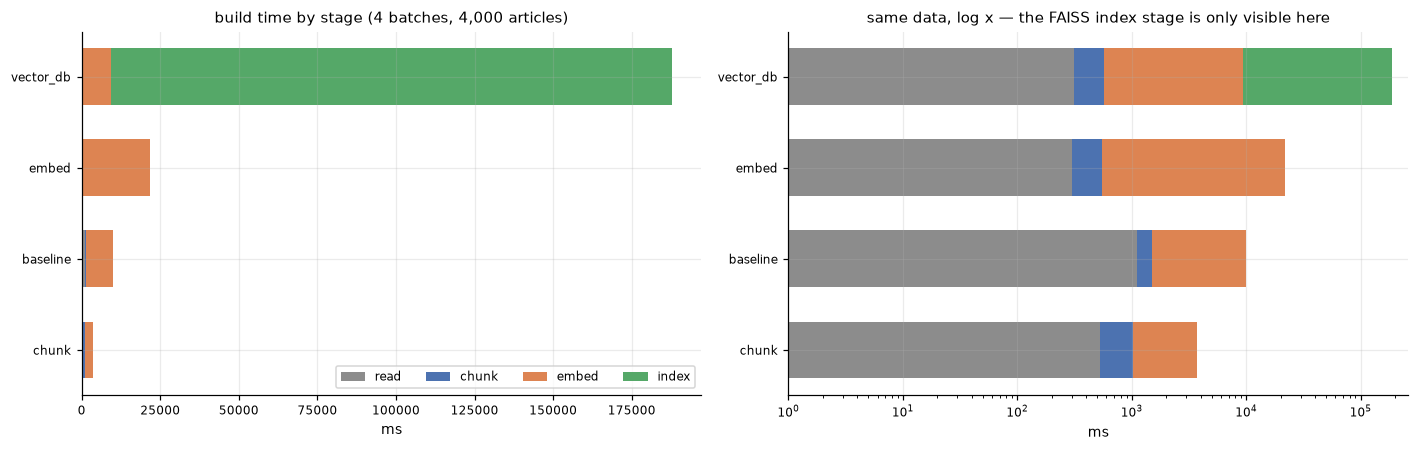

In [27]:
tbl = runs.set_index("arm")[[s + "_ms" for s in STAGES] + ["unaccounted_ms", "total_ms"]]
display(tbl.round(1))

order = list(runs.sort_values("total_ms")["arm"])
d = runs.set_index("arm").loc[order]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, logx in zip(axes, [False, True]):
    left = np.zeros(len(order))
    for s in STAGES:
        ax.barh(range(len(order)), d[s + "_ms"].values, left=left,
                color=STAGE_COLOR[s], label=s, height=0.62)
        left = left + d[s + "_ms"].values
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order)
    ax.set_xlabel("ms")
    if logx:
        ax.set_xscale("log")
        ax.set_xlim(left=1)
        ax.set_title("same data, log x — the FAISS index stage is only visible here")
    else:
        ax.set_title("build time by stage (4 batches, 4,000 articles)")
axes[0].legend(ncol=4, loc="lower right")
fig.tight_layout()
fig.savefig(FIGS / "build_time_by_stage.png", bbox_inches="tight")
plt.show()

,change,read_ms_x,chunk_ms_x,embed_ms_x,index_ms_x,total_ms_x
arm,,,,,,
baseline,- (reference),1.0,1.0,1.0,1.0,1.0
chunk,chunker.type=sentence,0.476354,1.269552,0.313795,0.186207,0.369482
embed,"embedder.metric=dot, embedder.model=multi-qa-m...",0.269705,0.644394,2.479891,1.17931,2.156335
vector_db,index.database=chroma,0.282841,0.659327,1.043666,12295.117241,18.656569


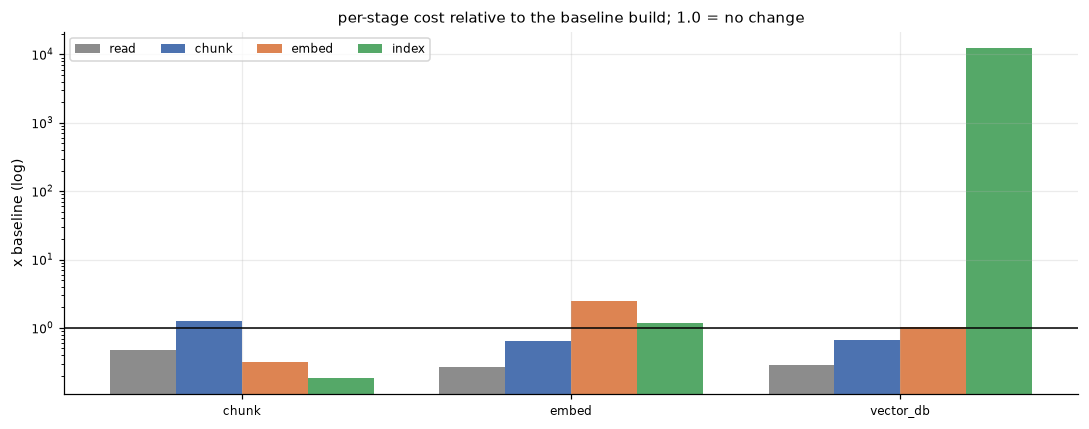

In [ ]:
base = runs.set_index("job_id").loc[BASELINE_JOB]
cols = [s + "_ms" for s in STAGES] + ["total_ms"]

absolute = runs.set_index("arm")[cols]
ratio    = (absolute / base[cols]).add_suffix("_x")
comp     = absolute.join(ratio).round(2)
comp.insert(0, "change", runs.set_index("arm")["change_vs_baseline"])
display(comp[["change"] + [c for c in comp.columns if c.endswith("_x")]])

arms = [a for a in runs["arm"] if a != ARM[BASELINE_JOB]]
fig, ax = plt.subplots(figsize=(10, 4))
w, x = 0.2, np.arange(len(arms))
for i, s in enumerate(STAGES):
    vals = [ratio.loc[a, s + "_ms_x"] for a in arms]
    ax.bar(x + (i - 1.5) * w, vals, w, color=STAGE_COLOR[s], label=s)
ax.axhline(1, color="k", lw=1)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(arms, fontsize=8)
ax.set_ylabel("x baseline (log)")
ax.set_title("per-stage cost relative to the baseline build; 1.0 = no change")
ax.legend(ncol=4)
fig.tight_layout()
fig.savefig(FIGS / "stage_ratio_vs_baseline.png", bbox_inches="tight")
plt.show()

**Read.**

- **Embedding dominates every FAISS arm** — 84% of the baseline build. `read` and `chunk`
  are together under 15%, and FAISS `flat` insertion is 0.1%. Any offline optimisation
  that is not about the embedder is optimising a rounding error *at this index type*; the
  picture changes once the index is IVF-PQ, where training and PQ encoding are real work
  that a `flat` build never performs.
- **The embedder swap is the big lever: 2.5x embed time** for mpnet vs MiniLM, on
  identical chunks. That is a 768-dim, 12-layer model against a 384-dim, 6-layer one.
- **The chunker swap looks 2.7x cheaper end-to-end, but not for a reason you can bank.**
  It is cheaper because it emitted 8.6x fewer chunks from the same text (section 5), and
  most of those chunks are longer than the embedder's context window. The saving is partly
  real (fewer sequences) and partly an artefact of text being silently truncated away.
- **Chroma turns the index stage from 0.1% into 95% of the build.** 178 s against FAISS's
  14.5 ms for the same 45,608 vectors — roughly four orders of magnitude. That is the cost
  of a persistent document store versus an in-memory flat array, and it is the single
  largest effect in the whole offline dataset.

## 3. Build time is a rounding error next to process setup

The trace records how long the process spent getting *ready* before any corpus work
started. That number dwarfs the builds, and it is why section 10's job-wide plots look
almost entirely idle.

,env_import_model_ms,env_chunker_ms,env_db_ms,warmup_ms,total_ms,env_total_ms,build_pct_of_process
arm,,,,,,,
baseline,1552757.4,3114.3,58436.3,636.8,10064.9,1614308.0,0.6
chunk,1546319.8,1258.7,59088.2,386.7,3718.8,1606666.7,0.2
embed,1570650.1,983.0,60709.1,358.7,21703.3,1632342.2,1.3
vector_db,1560049.3,1053.8,100754.6,446.0,187776.5,1661857.8,10.2


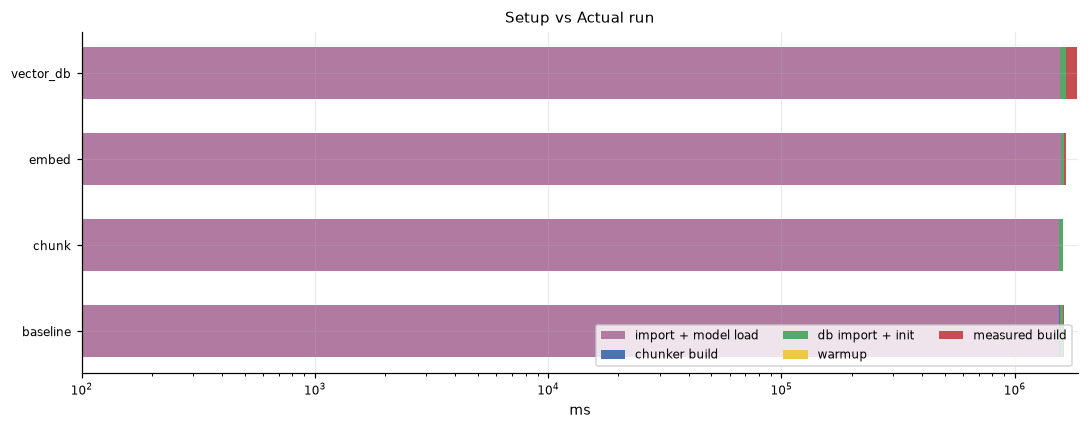

In [57]:
env = runs.set_index("arm")[["env_import_model_ms", "env_chunker_ms", "env_db_ms",
                             "warmup_ms", "total_ms", "env_total_ms"]].copy()
env["build_pct_of_process"] = 100 * env["total_ms"] / (env["env_total_ms"] + env["total_ms"])
display(env.round(1))

parts = [("env_import_model_ms", "import + model load", "#B07AA1"),
         ("env_chunker_ms",      "chunker build",       "#4C72B0"),
         ("env_db_ms",           "db import + init",    "#55A868"),
         ("warmup_ms",           "warmup",              "#EDC948"),
         ("total_ms",            "measured build",      "#C44E52")]

fig, ax = plt.subplots(figsize=(10, 4))
y, left = np.arange(len(env)), np.zeros(len(env))
for col, lab, c in parts:
    v = env[col].fillna(0).values
    ax.barh(y, v, left=left, color=c, label=lab, height=0.6)
    left = left + v
ax.set_yticks(y)
ax.set_yticklabels(env.index)
ax.set_xlabel("ms")
ax.set_xscale("log")
ax.set_xlim(left=100)
ax.set_title("Setup vs Actual run")
ax.legend(ncol=3, loc="lower right")
fig.tight_layout()
fig.savefig(FIGS / "setup_vs_build.png", bbox_inches="tight")
plt.show()

**Read.** ~26 minutes of import and model load against 3.7-188 s of build. The four FAISS
arms spend **under 1.5% of their process lifetime** doing the thing being benchmarked;
even the Chroma arm, with by far the longest build in the set, only reaches 10%.

Two consequences that belong in the write-up:

1. Any energy or utilisation figure computed over a whole hardware CSV is a statement
   about SLURM startup and model loading, not about RAG. Everything from section 9 onward
   aggregates only inside explicit stage windows.
2. `import_and_model_load` is ~1,550 s in *every* arm, including ones that differ only in
   chunker. It is not model-size-dependent, so it is filesystem and import cost on the
   shared cluster, not something the pipeline controls. That is also why it is excluded
   from the build comparison rather than folded into it — but it is a real operational
   cost of a cold run and should be quoted separately, not silently dropped.

## 4. Per-batch behaviour — is there a steady state?

The build processes `offline.file_chunk_size = 1000` articles per batch, four batches per
run. Whether batch 0 is slower than batches 1-3 tells you whether the run-level throughput
figure is a warm number or a cold one.

,baseline,chunk,embed,vector_db
batch_idx,,,,
0,5188.0,1757.0,2339.0,5065.0
1,5204.0,2221.0,1716.0,5164.0
2,5696.0,1703.0,2434.0,5558.0
3,5584.0,2730.0,2219.0,4775.0


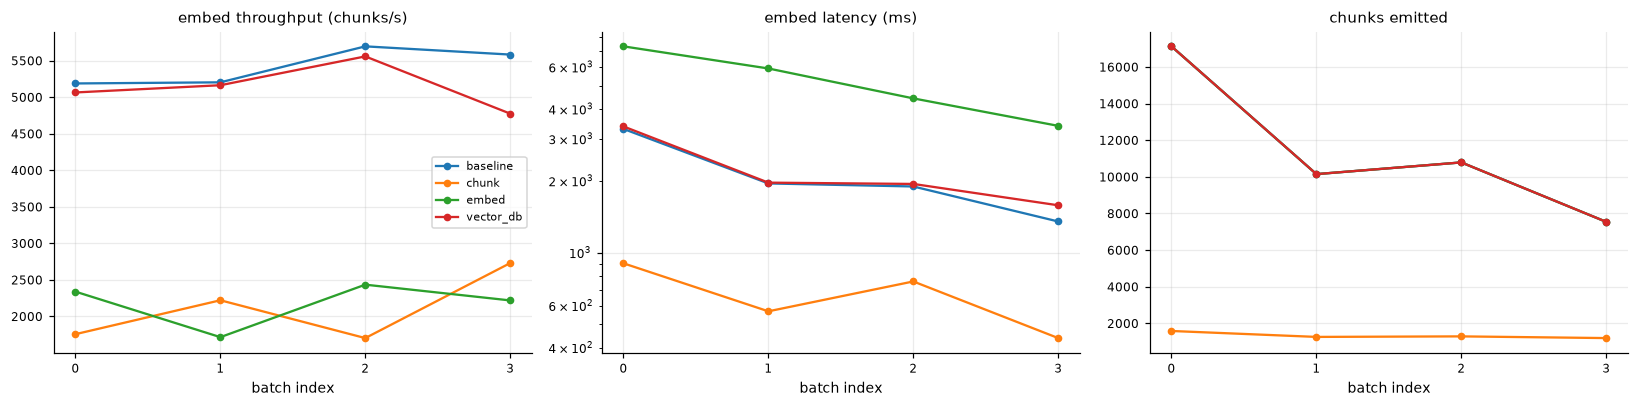

first-batch penalty (batch 0 embed chunks/s over the mean of batches 1-3):
  baseline                      0.94x   (batch0 5,188  vs  rest 5,495)
  chunk                         0.79x   (batch0 1,757  vs  rest 2,218)
  embed                         1.10x   (batch0 2,339  vs  rest 2,123)
  vector_db                     0.98x   (batch0 5,065  vs  rest 5,166)


In [30]:
piv = batches.pivot_table(index="batch_idx", columns="job_id", values="embed_chunks_s")
piv.columns = [ARM[c] for c in piv.columns]
display(piv.round(0))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, (col, lab) in zip(axes, [("embed_chunks_s", "embed throughput (chunks/s)"),
                                 ("embed_ms",       "embed latency (ms)"),
                                 ("n_chunks",       "chunks emitted")]):
    for job, g in batches.groupby("job_id"):
        g = g.sort_values("batch_idx")
        ax.plot(g["batch_idx"], g[col], marker="o", ms=4, label=ARM[job])
    ax.set_xlabel("batch index")
    ax.set_title(lab)
    ax.set_xticks([0, 1, 2, 3])
axes[1].set_yscale("log")
axes[0].legend(fontsize=7)
fig.tight_layout()
fig.savefig(FIGS / "per_batch_throughput.png", bbox_inches="tight")
plt.show()

print("first-batch penalty (batch 0 embed chunks/s over the mean of batches 1-3):")
for job, g in batches.groupby("job_id"):
    g = g.sort_values("batch_idx")
    b0, rest = g.iloc[0]["embed_chunks_s"], g.iloc[1:]["embed_chunks_s"].mean()
    print("  {:<28} {:5.2f}x   (batch0 {:,.0f}  vs  rest {:,.0f})".format(
        ARM[job], b0 / rest, b0, rest))

**Read.** Batch 0 runs within a few percent of the later batches in every arm, so the two
warmup rounds recorded in the trace did their job and the run-level rate is not dominated
by a cold first pass. What the batches do *not* give you is independent replication: they
share one process, one model load and one allocator state, so their spread is within-run
jitter, not run-to-run variance. Section 8 is the only place a genuine repeat exists.

Batch chunk counts vary by ~2x (7,543 to 17,126 for the baseline) purely because articles
differ in length — worth remembering when reading any single-batch number.

## 5. Hardware traces — fixing the columns first

`monitor.sh` invokes:

```
dcgmi dmon -e 203,204,155,1001,1002,1009,1010 -c 1 \
  | awk 'NR>2 { pw+=$4; gu+=$2; mc+=$3; gr+=$5; sm+=$6; ptx+=$7; prx+=$8; n++ } ...'
```

`dcgmi dmon` prints each row as `GPU <id> <v1> <v2> ...`, so the entity label occupies
**two** awk fields, not one. Every value is therefore read one column early. Two
signatures in the data confirm it beyond doubt:

- `dcgmi_gpu_util_pct` is the constant **0.5** in every row of every file — that is `$2`,
  the mean of the GPU *entity IDs* {0, 1}, not a utilisation.
- `dcgmi_gr_active` sits at **64.0-212.8**, an impossible range for a 0-1 activity ratio
  and an entirely sensible one for H100 watts; meanwhile `dcgmi_power_w` maxes out at
  **24.5**, which is a percentage.

The corrected mapping, applied on load below:

| CSV header | actually contains |
|---|---|
| `dcgmi_gpu_util_pct` | mean GPU entity id (constant — drop) |
| `dcgmi_mem_copy_util_pct` | GPU utilisation % (field `203`) |
| `dcgmi_power_w` | memory-copy utilisation % (`204`) |
| `dcgmi_gr_active` | **power, W** (`155`) |
| `dcgmi_sm_active` | graphics-engine active ratio (`1001`) |
| `dcgmi_pcie_tx_bytes` | SM active ratio (`1002`) |
| `dcgmi_pcie_rx_bytes` | PCIe TX bytes (`1009`) |
| — | PCIe RX (`1010`) is dropped entirely: `$9` is never summed |

The fix in `monitor.sh` is `pw+=$5; gu+=$3; mc+=$4; gr+=$6; sm+=$7; ptx+=$8; prx+=$9`.

Worth flagging that this was *believed fixed*: the CSV header was corrected to seven
correctly-named columns, but the awk offsets underneath it were not, so the header now
asserts a mapping the parser does not produce. Post-header-fix CSVs look more trustworthy
than pre-fix ones and are exactly as wrong. Check the awk line, not the header, before
trusting any future run.

**Second issue, not fixable in post:** `nvidia-smi` is filtered to the job's own device via
`CUDA_VISIBLE_DEVICES`, but `dcgmi dmon` is not — it reports every GPU entity on the node
and the awk averages them. With two entities and one allocated GPU, every DCGM number here
is *(ours + neighbour) / 2*. `gpu_mem_used_mb` is per-GPU and trustworthy; DCGM power and
activity are node-averaged and must be labelled as such wherever they are quoted.

In [43]:
DCGM_FIX = {
    "dcgmi_gpu_util_pct":      "dcgm_entity_id_mean",
    "dcgmi_mem_copy_util_pct": "gpu_util_pct_dcgm",
    "dcgmi_power_w":           "mem_copy_util_pct",
    "dcgmi_gr_active":         "power_w",
    "dcgmi_sm_active":         "gr_active",
    "dcgmi_pcie_tx_bytes":     "sm_active",
    "dcgmi_pcie_rx_bytes":     "pcie_tx_bytes",
}


def load_hw(kind="offline"):
    frames = []
    for p in find("hardware_" + kind + "_*.csv"):
        job = re.search(r"_(\d+)\.csv$", p.name).group(1)
        d = pd.read_csv(p, parse_dates=["timestamp"]).rename(columns=DCGM_FIX)
        d["job_id"] = job
        d["gpu_mem_GB"] = d["gpu_mem_used_mb"] / 1000   # GB, not GiB - matches the figures already recorded elsewhere
        frames.append(d)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


hw = load_hw()
hw = hw[hw.job_id.isin(JOBS)].copy()

sanity = hw.groupby("job_id").agg(
    n_samples=("timestamp", "size"),
    median_interval_s=("timestamp", lambda s: s.diff().dt.total_seconds().median()),
    dcgm_entity_id_mean=("dcgm_entity_id_mean", "mean"),
    idle_power_W=("power_w", lambda s: s.iloc[:60].mean()),
    max_power_W=("power_w", "max"),
    max_gr_active=("gr_active", "max"),
    peak_gpu_mem_GB=("gpu_mem_GB", "max"),
)
sanity.index = [ARM[i] for i in sanity.index]
display(sanity.round(2))
print("Post-fix sanity check: idle power near 64 W and activity ratios inside [0, 1].")
print("The raw headers give neither, which is how the mislabelling was found.")

,n_samples,median_interval_s,dcgm_entity_id_mean,idle_power_W,max_power_W,max_gr_active,peak_gpu_mem_GB
baseline,1163,1.0,0.5,64.63,122.83,0.12,4.67
chunk,1213,1.0,0.5,64.20,92.67,0.03,4.26
embed,1228,1.0,0.5,64.20,212.78,0.39,30.99
vector_db,1271,1.0,0.5,64.41,122.66,0.12,3.00


Post-fix sanity check: idle power near 64 W and activity ratios inside [0, 1].
The raw headers give neither, which is how the mislabelling was found.


## 6. The stage-overlaid hardware timeline

This is the plot the notebook exists for. For each run: hardware metrics on top, and
directly beneath them a ribbon showing exactly when `read`, `chunk`, `embed` and `index`
were running, batch by batch, on a shared time axis. Every hardware sample is drawn as a
marker so the sampling density is visible rather than hidden by line interpolation.

Two views per run — the whole job first, then the build window zoomed.

In [50]:
def stage_spans(job):
    # [(stage, t_start, t_end, batch_idx)] for every batch of a run.
    g = batches[batches.job_id == job].sort_values("batch_idx")
    return [(s, r[s + "_start"], r[s + "_end"], int(r["batch_idx"]))
            for _, r in g.iterrows() for s in STAGES]


def phase_spans(job):
    # Coarse process phases from the environment/warmup block.
    r = runs.set_index("job_id").loc[job]
    ph = [("import + model load", r.proc_start,     r.embedder_ready, "#B07AA1"),
          ("chunker build",       r.embedder_ready, r.chunker_ready,  "#4C72B0"),
          ("db import + init",    r.chunker_ready,  r.db_ready,       "#55A868")]
    if pd.notna(r.warmup_start):
        ph.append(("warmup", r.warmup_start, r.warmup_end, "#EDC948"))
    ph.append(("build", r.build_start, r.build_end, "#C44E52"))
    return ph


def draw_metrics(ax, d, t0, marker=True):
    x = (d["timestamp"] - t0).dt.total_seconds()
    ax.plot(x, d["power_w"], color="#C44E52", lw=1.2,
            marker="o" if marker else None, ms=3,
            label="GPU power (W")
    ax.set_ylabel("W")
    ax2 = ax.twinx(); ax2.grid(False)
    ax2.plot(x, d["gpu_mem_GB"], color="#4C72B0", lw=1.2,
             marker="s" if marker else None, ms=3,
             label="GPU mem (GB)")
    ax2.set_ylabel("GB")
    hs, ls_ = [], []
    for a in (ax, ax2):
        h, l = a.get_legend_handles_labels()
        hs += h; ls_ += l
    return ax2, hs, ls_


def draw_stage_ribbon(ax, job, t0, axis_span_s=None):
    # A stage shorter than ~1/250th of the axis is thinner than a pixel, so it also
    # gets a caret: without it the `index` row looks empty rather than fast.
    spans = stage_spans(job)
    thresh = (axis_span_s or 1.0) / 250.0
    for i, s in enumerate(STAGES):
        segs = [((st - t0).total_seconds(), max((en - st).total_seconds(), 1e-3))
                for stg, st, en, _ in spans if stg == s]
        ax.broken_barh(segs, (i - 0.38, 0.76), facecolors=STAGE_COLOR[s], edgecolor="none")
        tiny = [x0 + w / 2 for x0, w in segs if w < thresh]
        if tiny:
            ax.plot(tiny, [i] * len(tiny), marker="v", ms=5, lw=0,
                    color=STAGE_COLOR[s], clip_on=False)
    for _, r in batches[batches.job_id == job].sort_values("batch_idx").iterrows():
        xb = (r["read_start"] - t0).total_seconds()
        ax.axvline(xb, color="k", lw=0.5, alpha=0.35)
        ax.text(xb, -0.62, "b" + str(int(r.batch_idx)), fontsize=7, color="0.3",
                ha="left", va="bottom")
    ax.set_yticks(range(len(STAGES)))
    ax.set_yticklabels(STAGES)
    ax.set_ylim(3.6, -0.75)   # inverted: read at the top
    ax.grid(False)

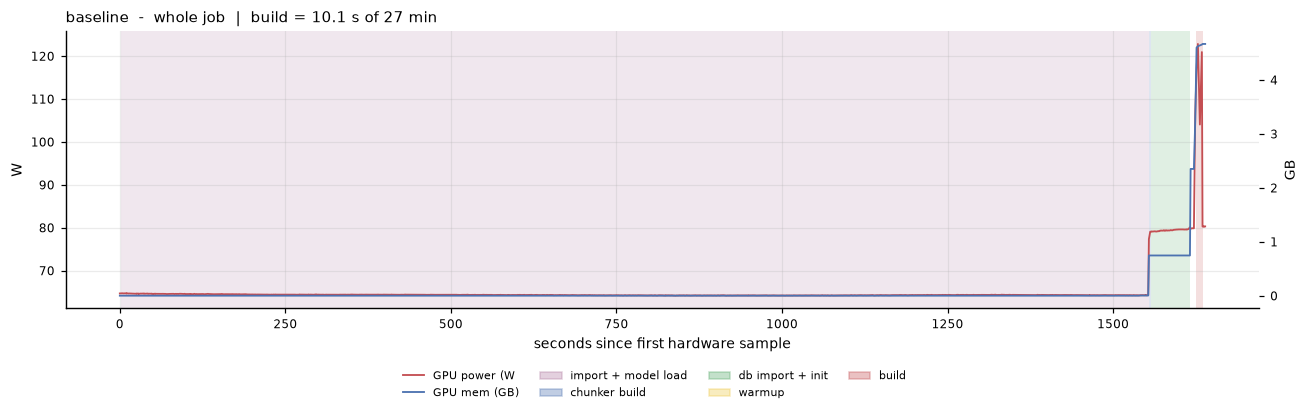

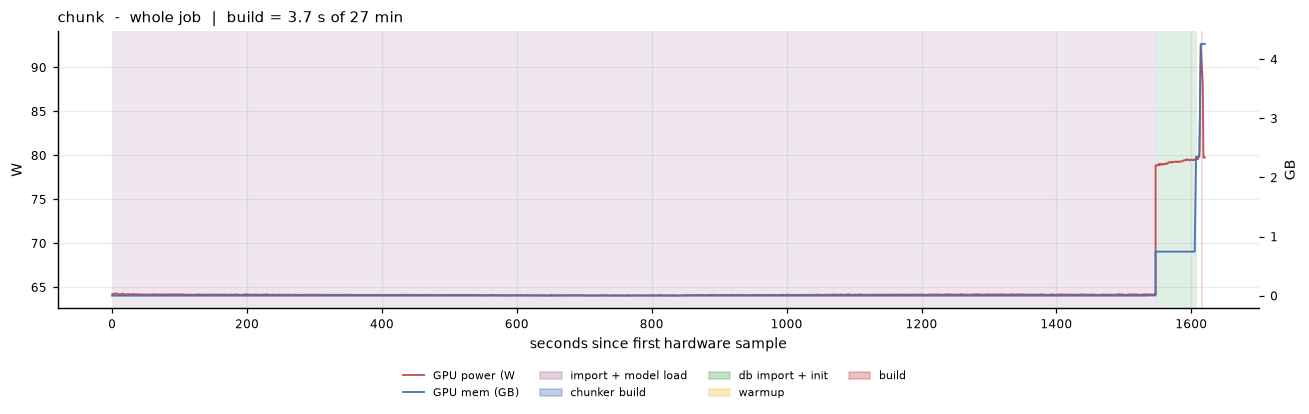

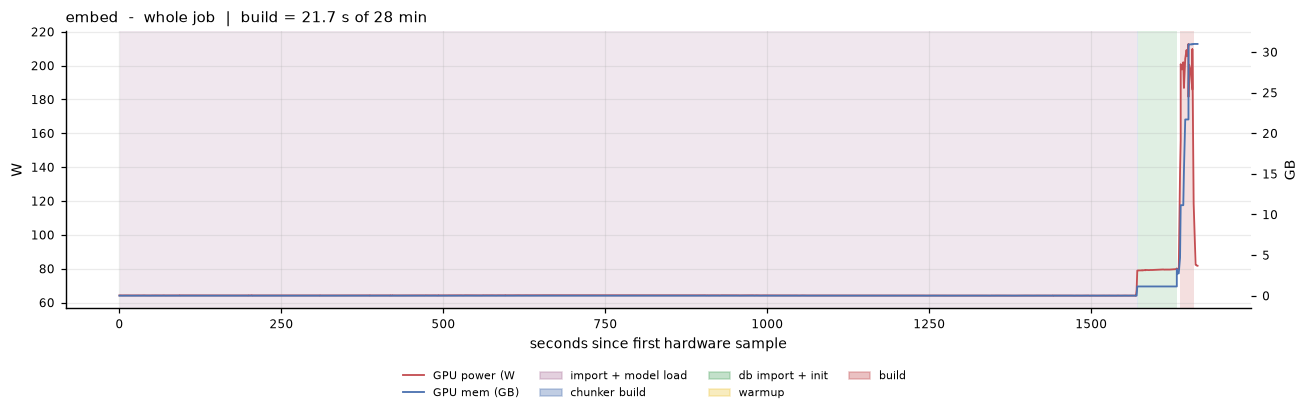

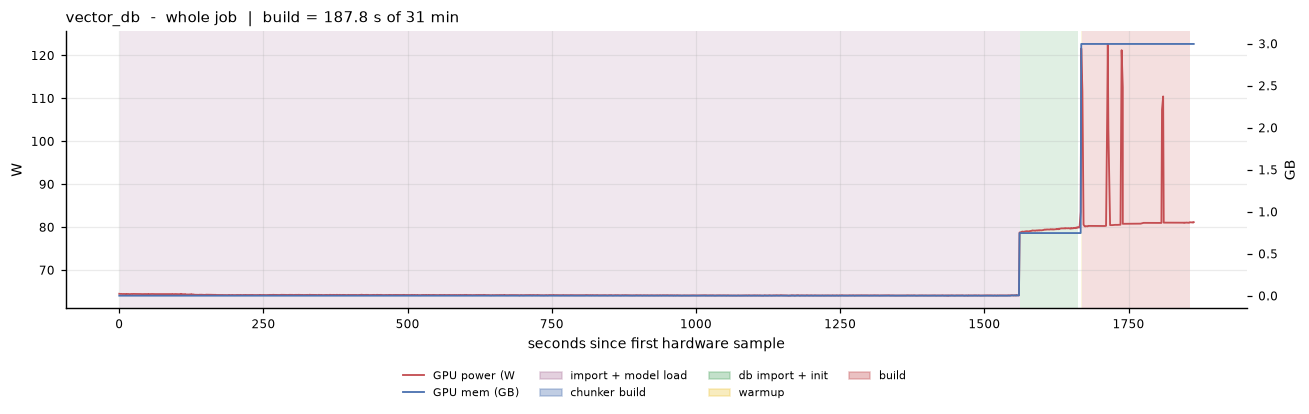

In [51]:
# --- View A: the whole job, coarse phases shaded --------------------------------
for job in JOBS:
    d = hw[hw.job_id == job]
    if d.empty:
        continue
    t0 = d["timestamp"].min()
    r  = runs.set_index("job_id").loc[job]

    fig, ax = plt.subplots(figsize=(12, 3.4))
    ax2, hs, ls_ = draw_metrics(ax, d, t0, marker=False)
    for lab, st, en, c in phase_spans(job):
        if pd.isna(st) or pd.isna(en):
            continue
        ax.axvspan((st - t0).total_seconds(), (en - t0).total_seconds(),
                   color=c, alpha=0.18, lw=0)
    job_min = (d.timestamp.max() - t0).total_seconds() / 60
    ax.set_title("{}  -  whole job  |  build = {:.1f} s of {:.0f} min".format(
        ARM[job], r.total_ms / 1000, job_min), loc="left")
    ax.set_xlabel("seconds since first hardware sample")
    ph = [Patch(color=c, alpha=0.35, label=l) for l, s_, e_, c in phase_spans(job)]
    fig.legend(hs + ph, ls_ + [p.get_label() for p in ph], ncol=4, fontsize=7,
               loc="upper center", bbox_to_anchor=(0.5, 0.02), frameon=False)
    fig.tight_layout()
    fig.savefig(FIGS / ("timeline_job_" + r.config + ".png"), bbox_inches="tight")
    plt.show()

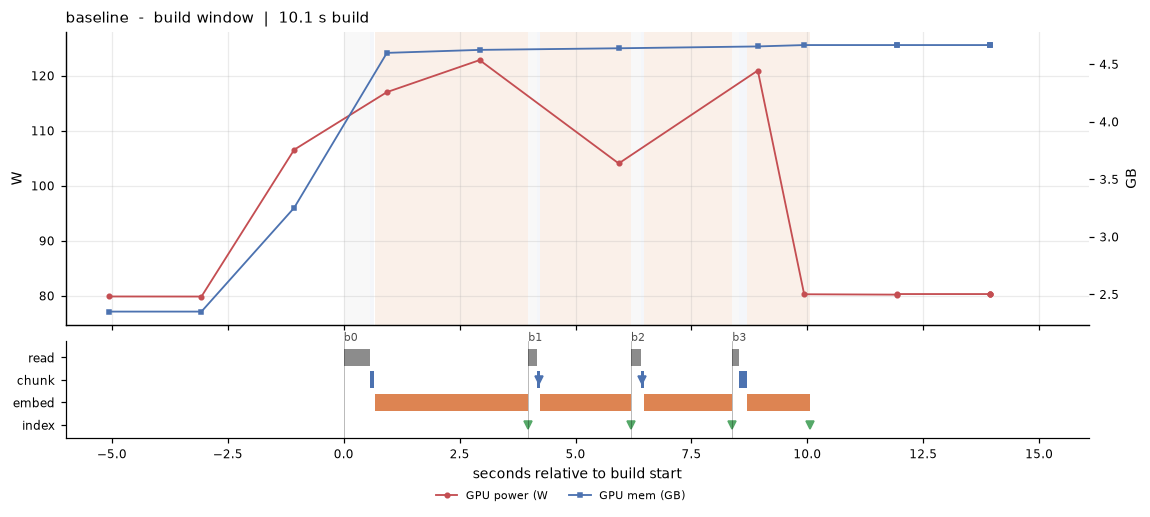

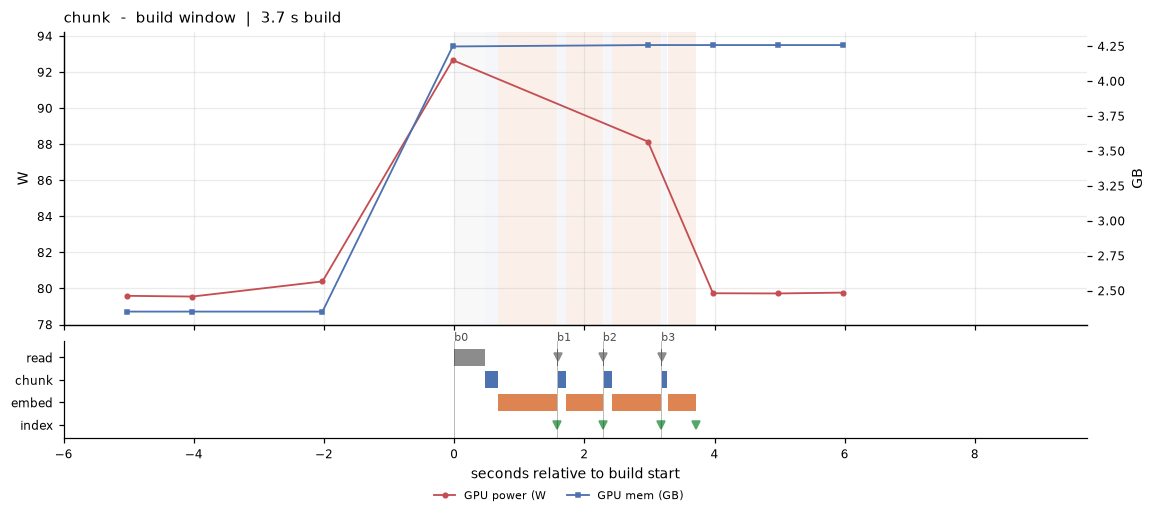

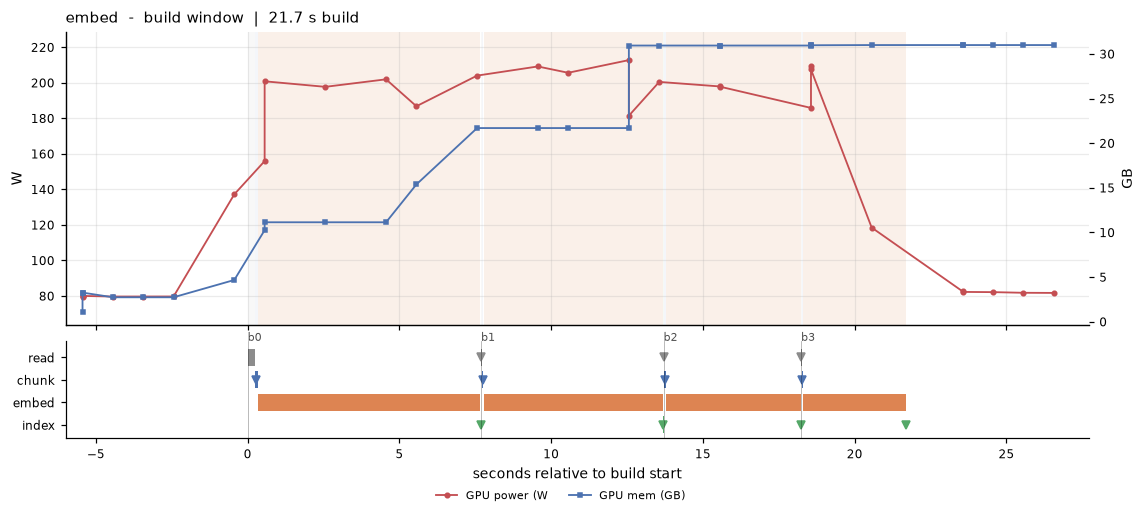

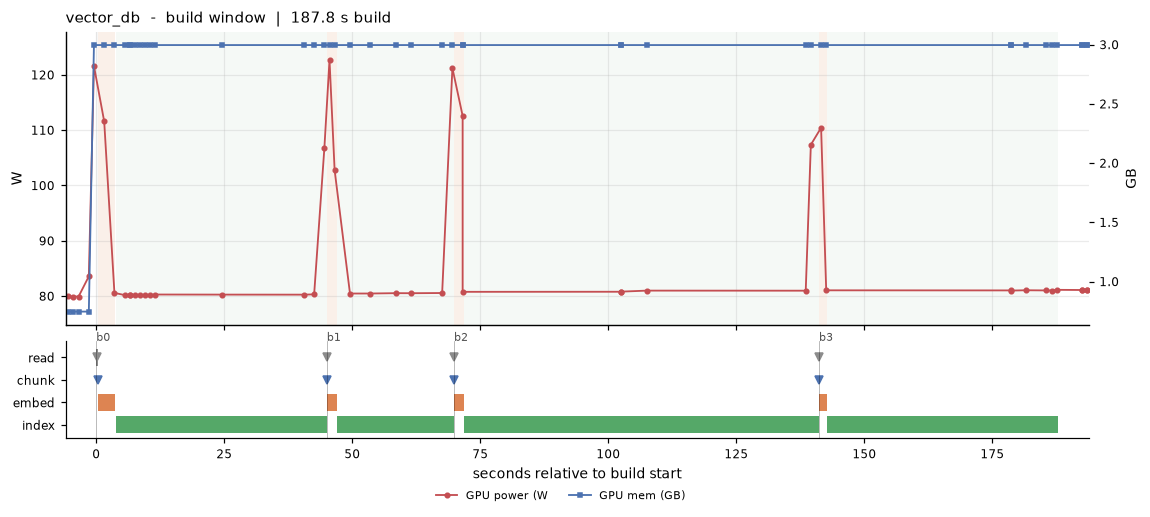

In [52]:
# --- View B: the build window, per-batch stage boundaries laid on top ------------
PAD_S = 6   # seconds of context either side of the build

for job in JOBS:
    d = hw[hw.job_id == job]
    r = runs.set_index("job_id").loc[job]
    if d.empty:
        continue
    lo = r.build_start - pd.Timedelta(seconds=PAD_S)
    hi = r.build_end   + pd.Timedelta(seconds=PAD_S)
    w  = d[(d.timestamp >= lo) & (d.timestamp <= hi)]
    t0 = r.build_start

    fig, (ax, axr) = plt.subplots(
        2, 1, figsize=(12, 4.8), sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08})

    ax2, hs, ls_ = draw_metrics(ax, w, t0)
    # Tie the metrics to the stages: shade each stage span behind the curves.
    for s, st, en, _ in stage_spans(job):
        ax.axvspan((st - t0).total_seconds(), (en - t0).total_seconds(),
                   color=STAGE_COLOR[s], alpha=0.12 if s == "embed" else 0.06, lw=0)
    n_in = int(((d.timestamp >= r.build_start) & (d.timestamp <= r.build_end)).sum())
    ax.set_title("{}  -  build window  |  {:.1f} s build".format(
        ARM[job], r.total_ms / 1000), loc="left")
    ax.margins(y=0.12)
    fig.legend(hs, ls_, ncol=3, fontsize=7, loc="upper center",
               bbox_to_anchor=(0.5, 0.03), frameon=False)

    axis_span = (hi - lo).total_seconds()
    draw_stage_ribbon(axr, job, t0, axis_span_s=axis_span)
    axr.set_xlabel("seconds relative to build start")
    axr.set_xlim((lo - t0).total_seconds(), (hi - t0).total_seconds())
    fig.savefig(FIGS / ("timeline_build_" + r.config + ".png"), bbox_inches="tight")
    plt.show()

## 7. How many samples actually land in each stage?

Before any hardware number is quoted, this is the table that decides whether it is allowed
to exist.

In [17]:
rows = []
for job in JOBS:
    d = hw[hw.job_id == job]
    if d.empty:
        continue
    r = runs.set_index("job_id").loc[job]
    agg = {}
    for s in STAGES:
        spans = [(st, en) for stg, st, en, _ in stage_spans(job) if stg == s]
        agg[s + "_s"] = round(sum((en - st).total_seconds() for st, en in spans), 3)
        agg[s + "_n"] = sum(int(((d.timestamp >= st) & (d.timestamp <= en)).sum())
                            for st, en in spans)
    inb = d[(d.timestamp >= r.build_start) & (d.timestamp <= r.build_end)]
    job_s = (d.timestamp.max() - d.timestamp.min()).total_seconds()
    row = {"arm": ARM[job], "build_s": round(r.total_ms / 1000, 1), "build_n": len(inb),
           "job_min": round(job_s / 60, 1),
           "build_pct_of_job": round(100 * (r.total_ms / 1000) / job_s, 2)}
    row.update(agg)
    rows.append(row)

dens = pd.DataFrame(rows).set_index("arm")
display(dens)
print("Rule applied below: a stage with fewer than ~10 samples gets no mean, no energy")
print("figure and no utilisation figure - only high-water marks.")

,build_s,build_n,job_min,build_pct_of_job,read_s,read_n,chunk_s,chunk_n,embed_s,embed_n,index_s,index_n
arm,,,,,,,,,,,,
baseline,10.1,5,27.3,0.61,1.104,0,0.394,0,8.496,5,0.013,0
chunk,3.7,1,27.0,0.23,0.525,0,0.502,0,2.665,1,0.002,0
embed,21.7,17,27.7,1.30,0.298,0,0.253,0,21.071,17,0.018,0
vector_db,187.8,37,31.1,10.08,0.313,0,0.259,0,8.868,8,178.279,29


Rule applied below: a stage with fewer than ~10 samples gets no mean, no energy
figure and no utilisation figure - only high-water marks.


## 8. GPU behaviour

Section 6 put power and memory on the timeline. This section puts **utilisation** there, and
then asks the three things a single utilisation curve cannot answer: how the arms compare on
one axis, whether the card was fed or left waiting, and whether the busy samples were
compute-bound or transfer-bound.

One scoping fact governs every number below. `monitor.sh` filters `nvidia-smi` to
`$CUDA_VISIBLE_DEVICES`, so `gpu_util_pct` and `gpu_mem_used_mb` describe **this job's own
card**. It does *not* filter `dcgmi` - the awk sums every row `dmon` prints and divides by the
count - so every `dcgm_*` column is a **mean over all cards on the node**. The next cell
recovers how many cards that was from `dcgm_entity_id_mean`, undilutes the DCGM ratios, and
checks the result against `gpu_util_pct`, the one column that was already job-scoped.

In [ ]:
# --- Which GPU columns describe THIS job, and which describe the node ---------
# nvidia-smi is filtered to $CUDA_VISIBLE_DEVICES by monitor.sh, so `gpu_util_pct`
# and `gpu_mem_used_mb` are the job's own card. dcgmi is NOT filtered - its awk
# averages every row dmon prints - so every dcgm column is a mean over all the
# cards on the node. `dcgm_entity_id_mean` is the mean of the entity ids it
# averaged over, which recovers how many that was: mean of {0..N-1} = (N-1)/2.
DCGM_GPUS = int(round(2 * hw["dcgm_entity_id_mean"].mean() + 1))

# Reconstruct the active card by undiluting that mean. Valid only while the other
# card(s) sit at zero on the metric in question; the check below says how often
# that assumption breaks, and power is deliberately NOT reconstructed because an
# idle card draws ~64 W, not 0.
DCGM_CEIL = {"gpu_util_pct_dcgm": 100.0, "mem_copy_util_pct": 100.0,
             "gr_active": 1.0, "sm_active": 1.0}
for c, ceil in DCGM_CEIL.items():
    hw[c + "_card"] = hw[c] * DCGM_GPUS
hw["pcie_tx_MBs"] = hw["pcie_tx_bytes"] * DCGM_GPUS / 1e6

over = {c: float((hw[c + "_card"] > ceil).mean() * 100) for c, ceil in DCGM_CEIL.items()}
print("dcgmi averaged over {} GPU(s); dcgm columns x{} to recover the active card."
      .format(DCGM_GPUS, DCGM_GPUS))
print("samples where the reconstruction exceeds its ceiling (other card was NOT idle):")
print("  " + ",  ".join("{}: {:.2f}%".format(k, v) for k, v in over.items()))
# Cross-check the reconstruction against the one column that is already job-scoped.
both = hw[(hw.gpu_util_pct > 0) & (hw.gpu_util_pct_dcgm > 0)]
if len(both):
    print("median gpu_util_pct / gpu_util_pct_dcgm on active samples: {:.2f}  (expect {})"
          .format(float((both.gpu_util_pct / both.gpu_util_pct_dcgm).median()), DCGM_GPUS))


def stage_label(d, job):
    # Name the stage each hardware sample fell inside; spans do not overlap.
    lab = pd.Series("outside build", index=d.index, dtype=object)
    for s, st, en, _ in stage_spans(job):
        lab[(d["timestamp"] >= st) & (d["timestamp"] <= en)] = s
    return lab


def build_window(job, pad_s=0):
    # Hardware rows inside a run's build, plus optional context either side.
    r = runs.set_index("job_id").loc[job]
    d = hw[hw.job_id == job]
    lo = r.build_start - pd.Timedelta(seconds=pad_s)
    hi = r.build_end   + pd.Timedelta(seconds=pad_s)
    return d[(d["timestamp"] >= lo) & (d["timestamp"] <= hi)], r


def n_note(n):
    # Every GPU figure carries its own sample count: at 1 Hz a 3.7 s build yields
    # one row, and a curve drawn through one row is not evidence of anything.
    return "n={} hw sample{}".format(n, "" if n == 1 else "s")


gpu_tbl = []
for job in JOBS:
    d = hw[hw.job_id == job]
    if d.empty:
        continue
    r  = runs.set_index("job_id").loc[job]
    b  = d[(d["timestamp"] >= r.build_start) & (d["timestamp"] <= r.build_end)]
    em = d[stage_label(d, job) == "embed"]
    gpu_tbl.append({
        "arm": ARM[job], "build_s": round(r.total_ms / 1000, 1),
        "n_build": len(b), "n_embed": len(em),
        "util_mean_build": b["gpu_util_pct"].mean(),
        "util_p95_build":  b["gpu_util_pct"].quantile(0.95) if len(b) else np.nan,
        "util_max_build":  b["gpu_util_pct"].max() if len(b) else np.nan,
        "util_mean_embed": em["gpu_util_pct"].mean() if len(em) else np.nan,
        "sm_active_max_card": b["sm_active_card"].max() if len(b) else np.nan,
        "peak_mem_GB": d["gpu_mem_GB"].max(),
        "mem_headroom_GB": (d["gpu_mem_total_mb"].max() - d["gpu_mem_used_mb"].max()) / 1000,
    })
gpu_tbl = pd.DataFrame(gpu_tbl).set_index("arm")
display(gpu_tbl.round(2))

**Read.**

- **The dilution is real and the correction is exact.** `dcgm_entity_id_mean` is 0.5 in every
  row of every file, so dcgmi averaged over **two** cards while SLURM gave the job one. The
  cross-check is unambiguous: on samples where both columns are non-zero, the median of
  `gpu_util_pct / gpu_util_pct_dcgm` is **2.00**, and *no* sample exceeds its ceiling after
  the x2. The neighbouring card was idle for the whole of every run.
- **Power is deliberately not reconstructed.** An idle H100 draws ~64 W, not 0 W, so the x2
  that works for a ratio would roughly double the true figure for watts. Section 6's power
  curve remains a two-card mean and must be labelled as one wherever it is quoted.
- **`dcgm_pcie_rx_bytes` does not survive at all.** The off-by-one diagnosed in section 5
  shifts every value one column left, so the last requested field falls off the end. Only
  PCIe **TX** exists in this data; the RX column in the CSV holds TX.

The utilisation columns themselves are trustworthy, and they already separate the arms: the
`embed` arm averages **67.7%** across its build and touches 100%, while `vector_db` averages
**3.0%** across 188 s because its 178 s `index` stage never touches the GPU at all.

In [ ]:
# --- 8.1  GPU utilisation over the run ---------------------------------------
# Left axis is utilisation only, 0-100, so the three curves share one scale and
# the eye is never asked to compare a percentage against a wattage.
UTIL_SERIES = [("gpu_util_pct",   "nvidia-smi util (this job's card)", "#C44E52", "-"),
               ("sm_active_card", "DCGM SM active x{}",                "#4C72B0", "--"),
               ("gr_active_card", "DCGM graphics active x{}",          "#55A868", ":")]


def draw_util(ax, d, t0, marker=True):
    x = (d["timestamp"] - t0).dt.total_seconds()
    ax.fill_between(x, 0, d["gpu_util_pct"], color="#C44E52", alpha=0.13, lw=0)
    for col, lab, c, ls in UTIL_SERIES:
        y = d[col] * (100.0 if col.endswith("active_card") else 1.0)
        ax.plot(x, y, color=c, lw=1.2, ls=ls, marker="o" if marker else None, ms=3,
                label=lab.format(DCGM_GPUS))
    ax.set_ylabel("% utilisation")
    ax.set_ylim(-4, 104)
    return ax


# View A: the whole job. Nearly all of it is import and model load, so this plot
# is mostly a flat zero - that IS the result, and section 3 is where it is read.
for job in JOBS:
    d = hw[hw.job_id == job]
    if d.empty:
        continue
    t0 = d["timestamp"].min()
    r  = runs.set_index("job_id").loc[job]

    fig, ax = plt.subplots(figsize=(12, 3.4))
    draw_util(ax, d, t0, marker=False)
    for lab, st, en, c in phase_spans(job):
        if pd.isna(st) or pd.isna(en):
            continue
        ax.axvspan((st - t0).total_seconds(), (en - t0).total_seconds(),
                   color=c, alpha=0.18, lw=0)
    job_min = (d["timestamp"].max() - t0).total_seconds() / 60
    ax.set_title("{}  -  GPU utilisation, whole job  |  build = {:.1f} s of {:.0f} min  |  {}"
                 .format(ARM[job], r.total_ms / 1000, job_min, n_note(len(d))), loc="left")
    ax.set_xlabel("seconds since first hardware sample")
    ax.legend(ncol=3, fontsize=7, loc="upper left", frameon=False)
    fig.savefig(FIGS / ("gpu_util_job_" + r.config + ".png"), bbox_inches="tight")
    plt.show()

In [ ]:
# View B: the build window, over the same per-batch stage ribbon section 6 uses.
GPU_PAD_S = 6

for job in JOBS:
    w, r = build_window(job, pad_s=GPU_PAD_S)
    if w.empty:
        print(ARM[job], "- no hardware samples in the build window, skipped")
        continue
    t0   = r.build_start
    n_in = len(build_window(job)[0])

    fig, (ax, axr) = plt.subplots(
        2, 1, figsize=(12, 4.8), sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08})

    draw_util(ax, w, t0)
    for s, st, en, _ in stage_spans(job):
        ax.axvspan((st - t0).total_seconds(), (en - t0).total_seconds(),
                   color=STAGE_COLOR[s], alpha=0.12 if s == "embed" else 0.06, lw=0)
    ax.set_title("{}  -  GPU utilisation, build window  |  {:.1f} s build  |  {} inside the build"
                 .format(ARM[job], r.total_ms / 1000, n_note(n_in)), loc="left")
    ax.legend(ncol=3, fontsize=7, loc="upper left", frameon=False)

    lo = (r.build_start - t0).total_seconds() - GPU_PAD_S
    hi = (r.build_end   - t0).total_seconds() + GPU_PAD_S
    draw_stage_ribbon(axr, job, t0, axis_span_s=hi - lo)
    axr.set_xlabel("seconds relative to build start")
    axr.set_xlim(lo, hi)
    fig.savefig(FIGS / ("gpu_util_build_" + r.config + ".png"), bbox_inches="tight")
    plt.show()

In [ ]:
# --- 8.2  Every arm on one axis ----------------------------------------------
# Left: real seconds, so a long build looks long. Right: build progress on 0-1,
# the only way to compare the SHAPE of a 3.7 s build against a 188 s one.
ARM_COLOR = {a: c for a, c in zip(sorted(runs["arm"]),
                                  ["#4C72B0", "#DD8452", "#55A868", "#C44E52",
                                   "#8172B3", "#937860", "#DA8BC3", "#8C8C8C"])}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for job in JOBS:
    w, r = build_window(job)
    if w.empty:
        continue
    secs = (w["timestamp"] - r.build_start).dt.total_seconds()
    span = (r.build_end - r.build_start).total_seconds()
    lab  = "{} ({})".format(ARM[job], n_note(len(w)))
    for ax, x in zip(axes, [secs, secs / span if span > 0 else secs]):
        ax.plot(x, w["gpu_util_pct"], marker="o", ms=4, lw=1.2,
                color=ARM_COLOR[ARM[job]], label=lab)

axes[0].set_xlabel("seconds since build start")
axes[0].set_ylabel("nvidia-smi GPU util (%)")
axes[0].set_title("absolute time", loc="left")
axes[0].set_ylim(-4, 104)
axes[1].set_xlabel("fraction of build elapsed")
axes[1].set_title("normalised to build length", loc="left")
axes[1].legend(fontsize=7, frameon=False)
fig.savefig(FIGS / "gpu_util_all_arms.png", bbox_inches="tight")
plt.show()

In [ ]:
# --- 8.3  GPU against CPU: is the card fed, or is it waiting? -----------------
# cpu_util_pct comes from /proc/stat and is a NODE-WIDE percentage over every
# core. One fully-saturated core on a 64-core node reads ~1.6%, which is why this
# column never leaves single digits and why it gets its own axis instead of
# sharing the GPU's 0-100. Read the SHAPE against the GPU curve, not the height.
for job in JOBS:
    w, r = build_window(job, pad_s=GPU_PAD_S)
    if len(w) < 2:
        print(ARM[job], "-", n_note(len(w)), "in the build window, too few to plot")
        continue
    t0 = r.build_start
    x  = (w["timestamp"] - t0).dt.total_seconds()

    fig, (ax, axr) = plt.subplots(
        2, 1, figsize=(12, 4.6), sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08})
    ax.plot(x, w["gpu_util_pct"], color="#C44E52", lw=1.3, marker="o", ms=3.5,
            label="GPU util (%, this job's card)")
    ax.fill_between(x, 0, w["gpu_util_pct"], color="#C44E52", alpha=0.12, lw=0)
    ax.set_ylabel("GPU util (%)")
    ax.set_ylim(-4, 104)

    ax2 = ax.twinx(); ax2.grid(False)
    ax2.plot(x, w["cpu_util_pct"], color="#4C72B0", lw=1.3, marker="s", ms=3.5,
             label="CPU util (%, whole node)")
    ax2.set_ylabel("CPU util (% of node)")
    ax2.set_ylim(bottom=0)

    # Correlation over the build window only, and only where there are enough
    # samples for the number to mean anything.
    ib  = build_window(job)[0]
    rho = ib["gpu_util_pct"].corr(ib["cpu_util_pct"]) if len(ib) >= 8 else np.nan
    rho_s = "r={:+.2f}".format(rho) if pd.notna(rho) else "r n/a (<8 samples)"
    ax.set_title("{}  -  GPU vs CPU over the build  |  {}  |  {}"
                 .format(ARM[job], n_note(len(ib)), rho_s), loc="left")
    hs, ls_ = [], []
    for a in (ax, ax2):
        h, l = a.get_legend_handles_labels()
        hs += h; ls_ += l
    ax.legend(hs, ls_, ncol=2, fontsize=7, loc="upper left", frameon=False)

    lo, hi = float(x.min()), float(x.max())
    draw_stage_ribbon(axr, job, t0, axis_span_s=hi - lo)
    axr.set_xlabel("seconds relative to build start")
    axr.set_xlim(lo, hi)
    fig.savefig(FIGS / ("gpu_vs_cpu_" + r.config + ".png"), bbox_inches="tight")
    plt.show()

In [ ]:
# --- 8.4  GPU memory: what was allocated, and what was left over --------------
# Panels 1 and 2 are the same curves on two x axes: absolute seconds, where the
# longest build compresses every other arm into the left edge, and fraction of
# build, where the allocation SHAPE of a 3.7 s build is comparable with a 188 s
# one. Sample counts here cover the padded window (+-GPU_PAD_S), so they exceed
# the in-build counts in gpu_tbl - the pad is what makes the step visible.
CARD_GB = float(hw["gpu_mem_total_mb"].max()) / 1000

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2),
                         gridspec_kw={"width_ratios": [2, 2, 1.6]}, sharey=False)

for job in JOBS:
    w, r = build_window(job, pad_s=GPU_PAD_S)
    if w.empty:
        continue
    secs = (w["timestamp"] - r.build_start).dt.total_seconds()
    span = (r.build_end - r.build_start).total_seconds()
    lab  = "{} (n={} in +-{}s window)".format(ARM[job], len(w), GPU_PAD_S)
    for ax, x in zip(axes[:2], [secs, secs / span if span > 0 else secs]):
        ax.step(x, w["gpu_mem_GB"], where="post", marker="o", ms=4, lw=1.3,
                color=ARM_COLOR[ARM[job]], label=lab)

axes[0].set_xlabel("seconds since build start")
axes[0].set_ylabel("GPU memory in use (GB)")
axes[0].set_title("allocation, absolute time", loc="left")
axes[1].set_xlabel("fraction of build elapsed")
axes[1].set_title("allocation, normalised to build length", loc="left")
axes[1].sharey(axes[0])
# A fixed +-6 s pad is +-1.6 build-lengths for the 3.7 s arm, which would stretch
# this axis to [-1.6, 2.6] and squash the build itself into the middle third.
axes[1].set_xlim(-0.15, 1.15)
axes[1].legend(fontsize=7, frameon=False)

# Peak against the card, so headroom is the thing you actually look at.
ax    = axes[2]
peaks = gpu_tbl["peak_mem_GB"].sort_values()
y     = np.arange(len(peaks))
ax.barh(y, [CARD_GB] * len(peaks), color="0.90", height=0.6)
ax.barh(y, peaks.values, height=0.6, color=[ARM_COLOR[a] for a in peaks.index])
for i, (a, v) in enumerate(peaks.items()):
    ax.text(v + CARD_GB * 0.03, i, "{:.1f} GB ({:.0f}%)".format(v, 100 * v / CARD_GB),
            va="center", fontsize=7)
ax.set_yticks(y); ax.set_yticklabels(peaks.index)
ax.set_xlabel("GB")
ax.set_xlim(0, CARD_GB * 1.55)
ax.set_title("peak vs the {:.0f} GB card".format(CARD_GB), loc="left")
# Explicit proxies: the peak bars are one colour per arm, so letting matplotlib
# pick a legend swatch would name every arm after whichever one drew last.
ax.legend(handles=[Patch(facecolor="0.90", label="card capacity"),
                   Patch(facecolor="0.45", label="peak in use (arm colour)")],
          fontsize=7, frameon=False, loc="lower right")
fig.savefig(FIGS / "gpu_memory.png", bbox_inches="tight")
plt.show()

In [ ]:
# --- 8.5  Compute-bound or transfer-bound? ------------------------------------
# Both axes of the left panel are dcgm columns diluted by the same factor, so the
# reconstruction scales them together: the SHAPE of the cloud does not depend on
# the undilution being exactly right, only its absolute position does.
pts = []
for job in JOBS:
    d = hw[hw.job_id == job].copy()
    if d.empty:
        continue
    d["stage"] = stage_label(d, job)
    d["arm"]   = ARM[job]
    pts.append(d[d["stage"] != "outside build"])
pts = pd.concat(pts, ignore_index=True) if pts else pd.DataFrame()

if pts.empty:
    print("No hardware samples land inside any stage - nothing to scatter.")
else:
    print("samples inside a stage, pooled over every arm:")
    print(pts.groupby("stage").size().reindex(STAGES).fillna(0).astype(int).to_string())

    # Colour carries the stage, marker shape carries the arm: the interesting
    # question is whether one arm sits somewhere the others do not, and a single
    # pooled colour would hide exactly that.
    ARM_MARK = dict(zip(sorted(runs["arm"]), ["o", "s", "^", "D", "v", "P", "X", "*"]))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
    for ax, ycol, ylab in [
            (axes[0], "mem_copy_util_pct_card", "DCGM memory-bandwidth util (%, reconstructed)"),
            (axes[1], "pcie_tx_MBs",            "DCGM PCIe TX (MB/s, reconstructed)")]:
        for s in STAGES:
            for arm, g in pts[pts["stage"] == s].groupby("arm"):
                ax.scatter(g["sm_active_card"] * 100, g[ycol], s=36, alpha=0.75,
                           color=STAGE_COLOR[s], marker=ARM_MARK[arm],
                           edgecolor="white", lw=0.4)
        ax.set_xlabel("DCGM SM active (%, reconstructed)")
        ax.set_ylabel(ylab)
    axes[0].set_title("compute occupancy vs on-card memory bandwidth", loc="left")
    axes[1].set_title("compute occupancy vs host->device traffic", loc="left")

    seen = pts.groupby("stage").size()
    axes[0].legend(handles=[Patch(facecolor=STAGE_COLOR[s], label="{} (n={})".format(s, seen[s]))
                            for s in STAGES if s in seen.index],
                   fontsize=7, frameon=False, title="stage", title_fontsize=7)
    axes[1].legend(handles=[plt.Line2D([], [], ls="", marker=ARM_MARK[a], color="0.35",
                                       ms=6, label=a) for a in sorted(pts["arm"].unique())],
                   fontsize=7, frameon=False, title="arm", title_fontsize=7)
    fig.savefig(FIGS / "gpu_compute_vs_transfer.png", bbox_inches="tight")
    plt.show()

**Read.**

- **Only the embedder arm makes the GPU work.** 67.7% mean utilisation and a 31 GB peak, vs
  4.7 GB and ~20% for the baseline. That is the 768-dim mpnet model against 384-dim MiniLM,
  and it is the same lever section 2 found in the timings - here it shows up as occupancy
  rather than seconds.
- **The Chroma arm is a CPU story wearing a GPU allocation.** Its four embed spikes reach
  ~22% and everything between them is flat zero while `index` runs on the host. Whatever the
  Chroma insert path costs, a GPU is not what it costs it on.
- **Nothing here is close to saturating the card.** The largest peak is 31 GB of 96 GB, 32%,
  and every other arm is under 5%. Batch size was not the binding constraint in any arm, so
  a throughput figure from these runs is not a statement about what the hardware can do.
- **SM-active tracks nvidia-smi closely but is coarsely quantised.** DCGM reports it to 0.1,
  which after the x2 lands every point on a 20% grid - readable as a corroborating signal,
  not as a precise second measurement.

**The sample counts are the limit on all of it.** At 1 Hz the four builds yield 5, 1, 17 and
37 in-window samples. The `chunk` arm's entire GPU story is *one row*, and its curves are
drawn through a single point. Every figure above prints its own n for that reason. These
plots are built to be read on the full runs; on `results_small` they are a wiring check, and
the only arm with enough samples to interpret honestly is `embed`.

Two things to re-check once the full-run dump is in `RESULTS_DIR`:

1. whether the inter-batch drops to 0% in the `embed` build window persist at scale - at four
   batches they could be either real reload gaps or a sampling artefact;
2. whether `index` stays GPU-idle once FAISS is IVF-PQ rather than `flat`, since training and
   PQ encoding are real work that a `flat` build never performs.